In [2]:
# ── Stage 5: Scoring Output, Explainability & Action Layer ────────────────
# Goal: Take lr_prob from Stage 4, produce final scored leads with
# per-lead SHAP explanations, tier assignments, and a summary dashboard.

import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shap
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict

warnings.filterwarnings("ignore")

# ── Paths (mirrors config.py) ──────────────────────────────────────────────
ROOT         = Path("..") 
DATA_PROC    = ROOT / "data" / "processed"
OUT_SCORES   = ROOT / "outputs" / "scores"
OUT_FIGURES  = ROOT / "outputs" / "figures"
OUT_REPORTS  = ROOT / "outputs" / "reports"
DOCS         = ROOT / "docs"

for p in [OUT_SCORES, OUT_FIGURES, OUT_REPORTS, DOCS]:
    p.mkdir(parents=True, exist_ok=True)

# ── Stage 4 model config (from config.py) ─────────────────────────────────
RANDOM_STATE = 42
CV_FOLDS     = 5
LR_C         = 0.1       # Best C from Stage 4 grid search

SCORE_TIERS = {
    "Hot":      (60, 100),
    "Warm":     (42,  59),
    "Nurture":  (25,  41),
    "Suppress": (  0,  24),
}

TIER_SLA = {
    "Hot":      "2-hour outreach",
    "Warm":     "24-hour outreach",
    "Nurture":  "Weekly nurture batch",
    "Suppress": "Monthly review only",
}

TIER_COLORS = {
    "Hot":      "#E63946",
    "Warm":     "#F4A261",
    "Nurture":  "#2A9D8F",
    "Suppress": "#ADB5BD",
}

print("✓ Imports and config loaded")

✓ Imports and config loaded


In [3]:
# ── Load feature matrix and Stage 4 scores ────────────────────────────────
features = pd.read_csv(DATA_PROC / "feature_matrix.csv")
scores   = pd.read_csv(ROOT / "outputs" / "scores" / "stage4_model_scores.csv")

print(f"Feature matrix:  {features.shape}")
print(f"Stage 4 scores:  {scores.shape}")
print(f"\nConverted leads: {scores['converted'].sum()} / {len(scores)} "
      f"({scores['converted'].mean():.1%})")

Feature matrix:  (800, 34)
Stage 4 scores:  (800, 7)

Converted leads: 204 / 800 (25.5%)


Rebuild LR Pipeline for SHAP

In [4]:
# ── Why rebuild? ───────────────────────────────────────────────────────────
# SHAP's LinearExplainer needs access to the fitted scaler + model weights,
# not just predictions. We retrain on the full dataset (same spec as Stage 4)
# to get a stable explainer. SHAP values will be consistent with lr_prob.

FEATURE_COLS = [c for c in features.columns if c != "lead_id"]

# Merge features with outcomes
df = features.merge(scores[["lead_id", "converted"]], on="lead_id")

X = df[FEATURE_COLS].fillna(0).values
y = df["converted"].values

# Rebuild pipeline: StandardScaler → LogisticRegression (C=0.1, balanced)
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(
                   C=LR_C,
                   max_iter=500,
                   class_weight="balanced",
                   random_state=RANDOM_STATE
               ))
])

pipeline.fit(X, y)

# Sanity check: in-sample AUC should be near 0.80
from sklearn.metrics import roc_auc_score
train_probs = pipeline.predict_proba(X)[:, 1]
print(f"In-sample AUC (full fit):  {roc_auc_score(y, train_probs):.3f}")
print(f"✓ Pipeline fitted on {len(X)} leads, {len(FEATURE_COLS)} features")

In-sample AUC (full fit):  0.827
✓ Pipeline fitted on 800 leads, 33 features


SHAP Explanation Engine

In [5]:
# ── SHAP LinearExplainer ───────────────────────────────────────────────────
# LinearExplainer computes exact SHAP values for linear models in O(n*p) time.
# shap_values[i, j] = contribution of feature j to lead i's log-odds prediction.
# Positive = pushed score UP, negative = pushed score DOWN.

scaler = pipeline.named_steps["scaler"]
lr_model = pipeline.named_steps["lr"]

# Background dataset: mean of training data (standard for LinearExplainer)
X_scaled = scaler.transform(X)
background = shap.maskers.Independent(X_scaled, max_samples=200)

explainer   = shap.LinearExplainer(lr_model, background)
shap_values = explainer(X_scaled)   # shape: (800, 33)

print(f"SHAP values shape: {shap_values.values.shape}")
print(f"✓ SHAP explanations computed for all {len(X)} leads")

SHAP values shape: (800, 33)
✓ SHAP explanations computed for all 800 leads


Score Mapping & Tier Assignment

In [6]:
# ── Map lr_prob → 0–100 score via percentile rescaling ───────────────────
# Why percentile-based (not linear)?
# Linear mapping compresses most leads into a narrow band since lr_prob
# isn't uniformly distributed. Percentile rescaling spreads the distribution
# across the full 0–100 range, making tier boundaries meaningful.
# We use lr_prob for ranking but the 0–100 score is the sales-facing number.

lr_prob = pipeline.predict_proba(X)[:, 1]

# Percentile rank → scale to 0–100
from scipy.stats import rankdata
percentile_rank = rankdata(lr_prob, method="average") / len(lr_prob)
score_0_100     = (percentile_rank * 100).round(1)

def assign_tier(score):
    for tier, (lo, hi) in SCORE_TIERS.items():
        if lo <= score <= hi:
            return tier
    return "Suppress"

tier = [assign_tier(s) for s in score_0_100]
sla  = [TIER_SLA[t] for t in tier]

print("Tier distribution:")
tier_series = pd.Series(tier)
for t in ["Hot", "Warm", "Nurture", "Suppress"]:
    n = (tier_series == t).sum()
    print(f"  {t:10s}: {n:4d} leads  ({n/len(tier):.1%})")

Tier distribution:
  Hot       :  321 leads  (40.1%)
  Warm      :  137 leads  (17.1%)
  Nurture   :  129 leads  (16.1%)
  Suppress  :  213 leads  (26.6%)


Per-Lead SHAP Explanations

In [8]:
# ── Generate top-3 positive + top negative signals per lead ───────────────
# For each lead:
#   1. Take SHAP values for that lead
#   2. Identify top 3 features by absolute positive contribution
#   3. Identify top 1 negative contributor (if any exists)
#   4. Map feature names to human-readable labels

FEATURE_LABELS = {
    "high_intent_touch_count":     "Multiple high-intent page visits",
    "visited_pricing_or_demo":     "Visited pricing or demo page",
    "cross_channel_engaged":       "Engaged across multiple channels",
    "dm_x_pricing_or_demo":        "Decision-maker visited pricing/demo",
    "pricing_page_visits_decayed": "Recent pricing page visit",
    "content_engagement_decayed":  "Recent content engagement",
    "smb_fit_x_intent":            "Strong SMB fit + high intent",
    "good_source_x_content":       "Quality lead source with content engagement",
    "demo_page_visits_decayed":    "Recent demo page visit",
    "open_rate":                   "High email open rate",
    "email_clicks_decayed":        "Recent email click activity",
    "email_opens_decayed":         "Recent email opens",
    "industry_tier":               "High-value industry",
    "lead_source_tier":            "High-quality lead source",
    "click_to_open_rate":          "High email click-to-open rate",
    "is_decision_maker":           "Is a decision-maker",
    "case_study_views_decayed":    "Recently viewed case studies",
    "company_size_score":          "Ideal company size",
    "trial_depth_score":           "Deep product trial engagement",
    "is_engaged_trial":            "Active trial user",
    "is_smb_fit":                  "Fits SMB profile",
    "senior_x_trial":              "Senior contact with trial activity",
    "seniority_rank":              "Senior job title",
    "visited_last_7_days":         "Visited site in last 7 days",
    "log_annual_revenue":          "High annual revenue",
    "tech_stack_score":            "Strong tech stack fit",
    "pages_per_session":           "High page depth per session",
    "roi_calculator_uses_decayed": "Used ROI calculator recently",
    "blog_views_decayed":          "High blog consumption",
    "is_unsubscribed":             "Unsubscribed from emails ↓",
    "careers_page_visits_decayed": "Visited careers page ↓",
    "is_hard_bounced":             "Email hard-bounced ↓",
    "is_bot_suspect":              "Suspected bot activity ↓",
}

def get_explanations(shap_row, feature_names, labels):
    sv = shap_row.values
    # Positive contributors (sorted descending)
    pos_idx = np.argsort(sv)[::-1]
    pos_reasons = []
    for i in pos_idx:
        if sv[i] > 0.01:  # threshold: meaningful contribution
            pos_reasons.append(labels.get(feature_names[i], feature_names[i]))
        if len(pos_reasons) == 3:
            break
    # Pad to 3 if needed
    while len(pos_reasons) < 3:
        pos_reasons.append("—")
    
    # Top negative contributor
    neg_idx = np.argsort(sv)
    top_neg = "—"
    if sv[neg_idx[0]] < -0.01:
        top_neg = labels.get(feature_names[neg_idx[0]], feature_names[neg_idx[0]])
    
    return pos_reasons[0], pos_reasons[1], pos_reasons[2], top_neg

explanations = [
    get_explanations(shap_values[i], FEATURE_COLS, FEATURE_LABELS)
    for i in range(len(X))
]

reason_1, reason_2, reason_3, top_negative = zip(*explanations)
print(f"✓ SHAP explanations generated for all {len(X)} leads")
print(f"\nExample (first Hot lead): explanation 1: {reason_1[0]}, explanation 2: {reason_2[0]}, explanation 3: {reason_3[0]}, top negative: {top_negative[0]}")

✓ SHAP explanations generated for all 800 leads

Example (first Hot lead): explanation 1: Email hard-bounced ↓, explanation 2: Visited site in last 7 days, explanation 3: Visited careers page ↓, top negative: Multiple high-intent page visits


Assemble Final Scored Dataset

In [9]:
# ── Build the sales-facing deliverable ────────────────────────────────────
final_df = pd.DataFrame({
    "lead_id":        df["lead_id"].values,
    "lr_prob":        lr_prob.round(4),
    "score_0_100":    score_0_100,
    "lr_percentile":  (percentile_rank * 100).round(1),
    "tier":           tier,
    "sla":            sla,
    "reason_1":       reason_1,
    "reason_2":       reason_2,
    "reason_3":       reason_3,
    "top_negative":   top_negative,
    "converted":      y,
})

final_df = final_df.sort_values("score_0_100", ascending=False).reset_index(drop=True)

# Save
out_path = OUT_SCORES / "stage5_final_scored_leads.csv"
final_df.to_csv(out_path, index=False)
print(f"✓ Saved: {out_path}")
print(f"\nShape: {final_df.shape}")
print("\nTop 5 leads:")
display(final_df[["lead_id","score_0_100","tier","reason_1","reason_2","top_negative"]].head(5))

✓ Saved: ../outputs/scores/stage5_final_scored_leads.csv

Shape: (800, 11)

Top 5 leads:


,lead_id,score_0_100,tier,reason_1,reason_2,top_negative
0,L00038,100.0,Hot,Multiple high-intent page visits,Recent content engagement,Recent email opens
1,L00298,99.9,Hot,Recent pricing page visit,Multiple high-intent page visits,Used ROI calculator recently
2,L00570,99.8,Hot,Multiple high-intent page visits,Recent content engagement,High-value industry
3,L00131,99.6,Hot,Multiple high-intent page visits,Recent pricing page visit,Recent email opens
4,L00063,99.5,Hot,Recent content engagement,High-value industry,Visited careers page ↓


Dashboard: Tier Distribution & Conversion Rates

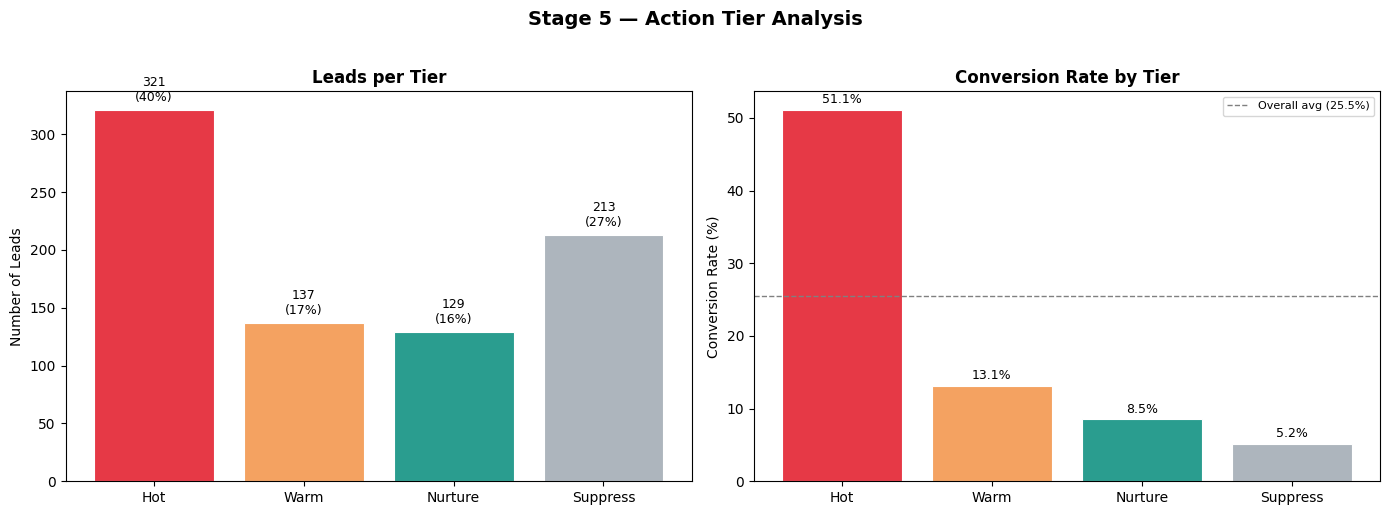

✓ Saved: stage5_tier_analysis.png


In [10]:
# ── Plot 1: Tier sizes and conversion rates ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Stage 5 — Action Tier Analysis", fontsize=14, fontweight="bold", y=1.02)

tier_order = ["Hot", "Warm", "Nurture", "Suppress"]
tier_stats = (final_df.groupby("tier")
              .agg(lead_count=("lead_id", "count"),
                   conversions=("converted", "sum"))
              .assign(conv_rate=lambda d: d["conversions"] / d["lead_count"])
              .reindex(tier_order))

# Left: lead count per tier
bars = axes[0].bar(
    tier_order,
    tier_stats["lead_count"],
    color=[TIER_COLORS[t] for t in tier_order],
    edgecolor="white", linewidth=0.8
)
axes[0].set_title("Leads per Tier", fontweight="bold")
axes[0].set_ylabel("Number of Leads")
axes[0].set_xlabel("")
for bar, (tier, row) in zip(bars, tier_stats.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"{int(row['lead_count'])}\n({row['lead_count']/len(final_df):.0%})",
                 ha="center", va="bottom", fontsize=9)

# Right: conversion rate per tier
bars2 = axes[1].bar(
    tier_order,
    tier_stats["conv_rate"] * 100,
    color=[TIER_COLORS[t] for t in tier_order],
    edgecolor="white", linewidth=0.8
)
axes[1].set_title("Conversion Rate by Tier", fontweight="bold")
axes[1].set_ylabel("Conversion Rate (%)")
axes[1].axhline(final_df["converted"].mean() * 100, color="gray",
                linestyle="--", linewidth=1, label=f"Overall avg ({final_df['converted'].mean():.1%})")
axes[1].legend(fontsize=8)
for bar, (tier, row) in zip(bars2, tier_stats.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{row['conv_rate']:.1%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_FIGURES / "stage5_tier_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: stage5_tier_analysis.png")

Dashboard: Conversion Capture & Cumulative Lift

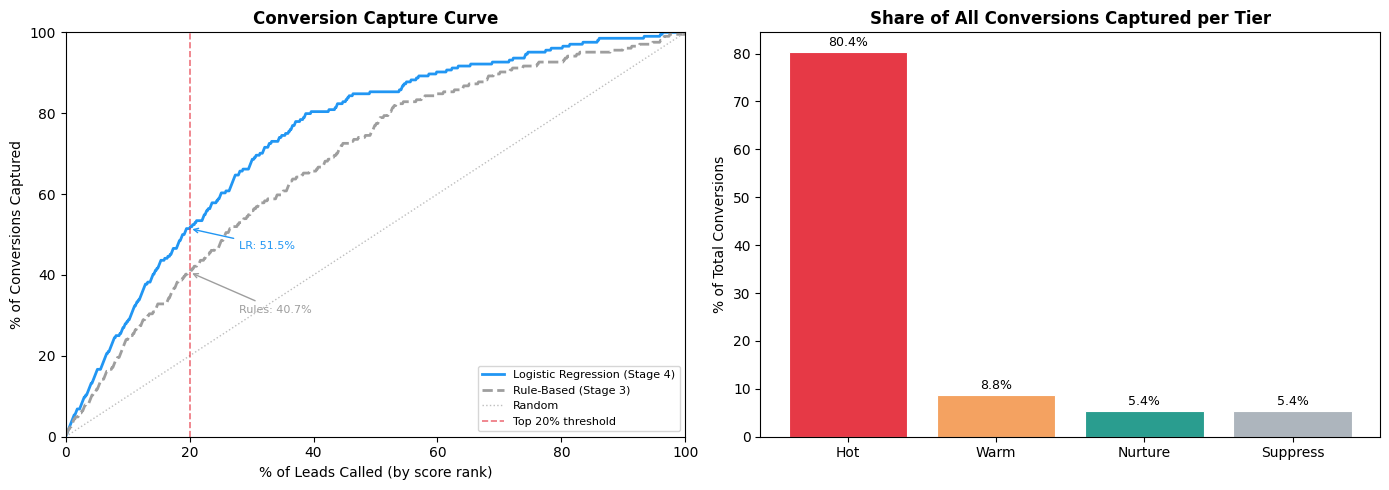

✓ Saved: stage5_conversion_capture.png


In [11]:
# ── Plot 2: Conversion capture curve + tier capture breakdown ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: cumulative conversion capture (model vs baseline vs random)
baseline_scores = scores.set_index("lead_id")["rule_based_score"]
final_with_baseline = final_df.merge(
    scores[["lead_id", "rule_based_score"]], on="lead_id"
)

def capture_curve(sorted_converted):
    cumsum = np.cumsum(sorted_converted)
    total  = sorted_converted.sum()
    return cumsum / total * 100

n = len(final_with_baseline)
pct_called = np.arange(1, n + 1) / n * 100

# LR model
lr_order   = final_with_baseline.sort_values("lr_prob", ascending=False)["converted"].values
# Rule-based
rb_order   = final_with_baseline.sort_values("rule_based_score", ascending=False)["converted"].values

axes[0].plot(pct_called, capture_curve(lr_order),
             color="#2196F3", linewidth=2, label=f"Logistic Regression (Stage 4)")
axes[0].plot(pct_called, capture_curve(rb_order),
             color="#9E9E9E", linewidth=2, linestyle="--", label="Rule-Based (Stage 3)")
axes[0].plot([0, 100], [0, 100], color="#BDBDBD", linewidth=1,
             linestyle=":", label="Random")
axes[0].axvline(20, color="#E63946", linewidth=1.2, linestyle="--", alpha=0.7,
                label="Top 20% threshold")

# Annotate capture rates at 20%
idx_20 = int(0.20 * n) - 1
lr_cap = capture_curve(lr_order)[idx_20]
rb_cap = capture_curve(rb_order)[idx_20]
axes[0].annotate(f"LR: {lr_cap:.1f}%", xy=(20, lr_cap),
                 xytext=(28, lr_cap - 5), fontsize=8, color="#2196F3",
                 arrowprops=dict(arrowstyle="->", color="#2196F3", lw=1))
axes[0].annotate(f"Rules: {rb_cap:.1f}%", xy=(20, rb_cap),
                 xytext=(28, rb_cap - 10), fontsize=8, color="#9E9E9E",
                 arrowprops=dict(arrowstyle="->", color="#9E9E9E", lw=1))

axes[0].set_title("Conversion Capture Curve", fontweight="bold")
axes[0].set_xlabel("% of Leads Called (by score rank)")
axes[0].set_ylabel("% of Conversions Captured")
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 100); axes[0].set_ylim(0, 100)

# Right: what % of ALL conversions does each tier hold?
total_conv = final_df["converted"].sum()
tier_conv_pct = (tier_stats["conversions"] / total_conv * 100).round(1)

bars = axes[1].bar(tier_order, tier_conv_pct,
                   color=[TIER_COLORS[t] for t in tier_order],
                   edgecolor="white", linewidth=0.8)
axes[1].set_title("Share of All Conversions Captured per Tier",
                  fontweight="bold")
axes[1].set_ylabel("% of Total Conversions")
for bar, val in zip(bars, tier_conv_pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_FIGURES / "stage5_conversion_capture.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: stage5_conversion_capture.png")

Dashboard: Global SHAP Feature Importance

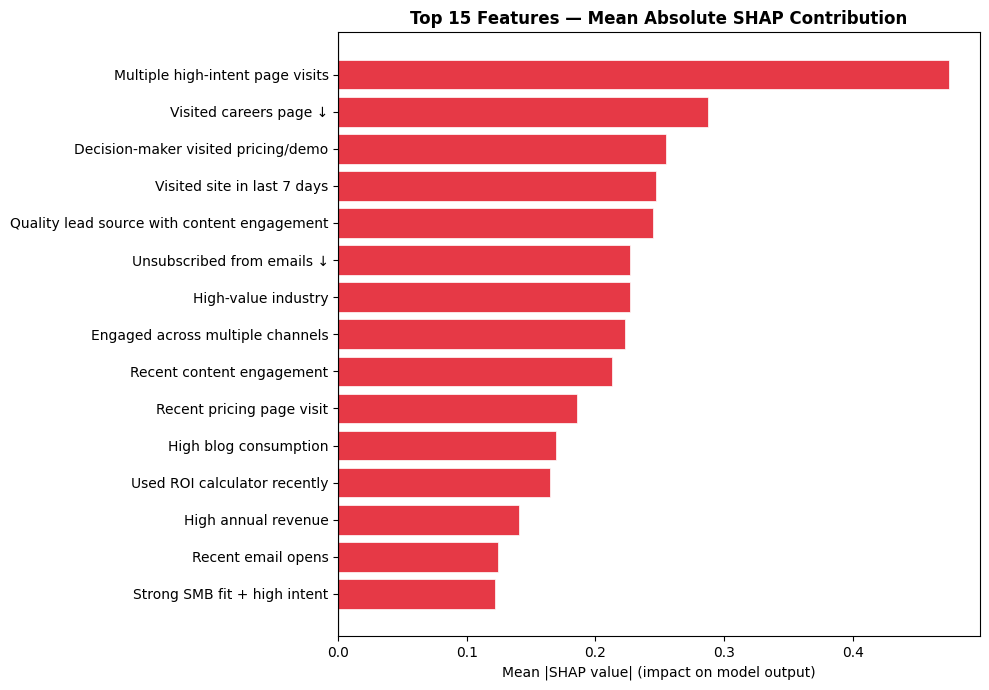

✓ Saved: stage5_shap_importance.png


In [12]:
# ── Plot 3: SHAP summary — mean absolute contribution per feature ──────────
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance = (pd.Series(mean_abs_shap, index=FEATURE_COLS)
                   .sort_values(ascending=True)
                   .tail(15))   # top 15 features

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#E63946" if v > 0 else "#2196F3"
          for v in shap_importance.values]
bars = ax.barh(
    [FEATURE_LABELS.get(f, f) for f in shap_importance.index],
    shap_importance.values,
    color="#E63946", edgecolor="white", linewidth=0.5
)
ax.set_title("Top 15 Features — Mean Absolute SHAP Contribution",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Mean |SHAP value| (impact on model output)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(OUT_FIGURES / "stage5_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: stage5_shap_importance.png")

Dashboard: Sample Lead Cards

In [13]:
# ── Lead Cards: 3 representative examples ─────────────────────────────────
# One Hot, one Warm, one borderline Nurture — to show how explanations
# differ across the score spectrum. This is the output a sales rep would see.

def print_lead_card(row):
    tier_emoji = {"Hot": "🔥", "Warm": "🌤️", "Nurture": "🌱", "Suppress": "⏸️"}
    print(f"{'─'*55}")
    print(f"  {tier_emoji[row.tier]} Lead ID: {row.lead_id}")
    print(f"  Score:      {row.score_0_100:.0f} / 100  (Top {100 - row.lr_percentile:.0f}%ile)")
    print(f"  Tier:       {row.tier}  •  SLA: {row.sla}")
    print(f"  Conv. prob: {row.lr_prob:.1%}")
    print(f"")
    print(f"  WHY THIS SCORE:")
    print(f"  ✅  {row.reason_1}")
    if row.reason_2 != "—":
        print(f"  ✅  {row.reason_2}")
    if row.reason_3 != "—":
        print(f"  ✅  {row.reason_3}")
    if row.top_negative != "—":
        print(f"  ⚠️   {row.top_negative}")
    print(f"{'─'*55}\n")

# Pick one representative per tier (highest score in each)
for tier_name in ["Hot", "Warm", "Nurture"]:
    sample = final_df[final_df["tier"] == tier_name].iloc[0]
    print_lead_card(sample)

───────────────────────────────────────────────────────
  🔥 Lead ID: L00038
  Score:      100 / 100  (Top 0%ile)
  Tier:       Hot  •  SLA: 2-hour outreach
  Conv. prob: 97.2%

  WHY THIS SCORE:
  ✅  Multiple high-intent page visits
  ✅  Recent content engagement
  ✅  Recent pricing page visit
  ⚠️   Recent email opens
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  🌤️ Lead ID: L00314
  Score:      59 / 100  (Top 41%ile)
  Tier:       Warm  •  SLA: 24-hour outreach
  Conv. prob: 46.8%

  WHY THIS SCORE:
  ✅  Decision-maker visited pricing/demo
  ✅  Visited site in last 7 days
  ✅  Engaged across multiple channels
  ⚠️   Visited careers page ↓
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  🌱 Lead ID: L00097
  Score:      41 / 100  (Top 59%ile)
  Tier:       Nurture  •  SLA: Weekly nurture batch
  Conv. prob: 31.3%

  WHY THIS SCORE:
  ✅  Recent content e

Model vs Baseline Summary Table

In [14]:
# ── Final comparison table ─────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score, average_precision_score

rb_probs  = final_with_baseline["rule_based_score"] / 100
lr_probs_ = final_with_baseline["lr_prob"]
actuals   = final_with_baseline["converted"]

idx_20 = int(0.20 * len(final_with_baseline))

rb_top20_cap  = (final_with_baseline.sort_values("rule_based_score", ascending=False)
                 .head(idx_20)["converted"].sum() / actuals.sum())
lr_top20_cap  = (final_with_baseline.sort_values("lr_prob", ascending=False)
                 .head(idx_20)["converted"].sum() / actuals.sum())

summary = pd.DataFrame({
    "Metric": ["AUC-ROC", "Avg Precision (AP)", "Top-20% Conversion Capture",
               "Hot Tier Conversion Rate", "Hot + Warm Conversion Capture"],
    "Rule-Based (Stage 3)": [
        f"{roc_auc_score(actuals, rb_probs):.3f}",
        f"{average_precision_score(actuals, rb_probs):.3f}",
        f"{rb_top20_cap:.1%}",
        f"{tier_stats.loc['Hot','conv_rate']:.1%} (approx)",
        "—",
    ],
    "Logistic Regression (Stage 5)": [
        f"{roc_auc_score(actuals, lr_probs_):.3f}",
        f"{average_precision_score(actuals, lr_probs_):.3f}",
        f"{lr_top20_cap:.1%}",
        f"{tier_stats.loc['Hot','conv_rate']:.1%}",
        f"{(tier_stats.loc[['Hot','Warm'],'conversions'].sum() / total_conv):.1%}",
    ],
})

display(summary.set_index("Metric"))
summary.to_csv(OUT_REPORTS / "stage5_model_comparison.csv", index=False)
print("✓ Saved: stage5_model_comparison.csv")

,Rule-Based (Stage 3),Logistic Regression (Stage 5)
Metric,,
AUC-ROC,0.739,0.827
Avg Precision (AP),0.494,0.644
Top-20% Conversion Capture,40.7%,51.5%
Hot Tier Conversion Rate,51.1% (approx),51.1%
Hot + Warm Conversion Capture,—,89.2%


✓ Saved: stage5_model_comparison.csv


Save Notebook Metadata & Print Completion

In [16]:
# ── Stage 5 complete ──────────────────────────────────────────────────────
print("=" * 55)
print("  STAGE 5 — COMPLETE")
print("=" * 55)
print(f"\n  Scored leads:  {OUT_SCORES / 'stage5_final_scored_leads.csv'}")
print(f"  Figures:       {OUT_FIGURES}/stage5_*.png  (3 plots)")
print(f"  Report:        {OUT_REPORTS / 'stage5_model_comparison.csv'}")
print(f"\n  Leads by tier:")
for t in tier_order:
    row = tier_stats.loc[t]
    print(f"    {t:10s}: {int(row['lead_count']):4d} leads  "
          f"| conv rate {row['conv_rate']:.1%}  "
          f"| {row['conversions']:.0f} conversions captured")
print(f"\n  Total conversions accounted for: {total_conv}")
print(f"  Overall conversion rate:         {final_df['converted'].mean():.1%}")

  STAGE 5 — COMPLETE

  Scored leads:  ../outputs/scores/stage5_final_scored_leads.csv
  Figures:       ../outputs/figures/stage5_*.png  (3 plots)
  Report:        ../outputs/reports/stage5_model_comparison.csv

  Leads by tier:
    Hot       :  321 leads  | conv rate 51.1%  | 164 conversions captured
    Warm      :  137 leads  | conv rate 13.1%  | 18 conversions captured
    Nurture   :  129 leads  | conv rate 8.5%  | 11 conversions captured
    Suppress  :  213 leads  | conv rate 5.2%  | 11 conversions captured

  Total conversions accounted for: 204
  Overall conversion rate:         25.5%


In [20]:
# convert this notebook to a script for Stage 5 scoring output
#!jupyter nbconvert --to script 05_scoring_output.ipynb --output ../src/stage5_scoring_output.py